In [2]:
import pandas as pd

df = pd.read_csv("dataset_estres_vegetal_cdmx.csv")

df.head()

,fecha,hora,humedad,temperatura,viento,luz_solar,riesgo
0,2026-05-01,07:00,88,16,3,Baja,Bajo
1,2026-05-01,08:00,85,17,4,Baja,Bajo
2,2026-05-01,09:00,82,19,5,Media,Bajo
3,2026-05-01,10:00,78,21,6,Media,Bajo
4,2026-05-01,11:00,74,23,7,Media,Bajo


In [3]:
df.shape

(100, 7)

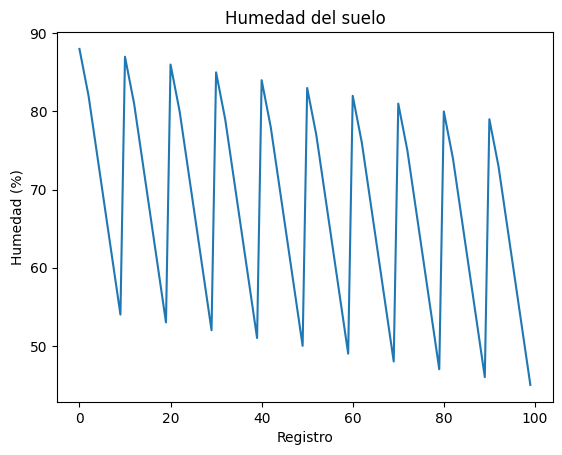

In [6]:
import matplotlib.pyplot as plt

plt.plot(df["humedad"])
plt.title("Humedad del suelo")
plt.xlabel("Registro")
plt.ylabel("Humedad (%)")
plt.show()

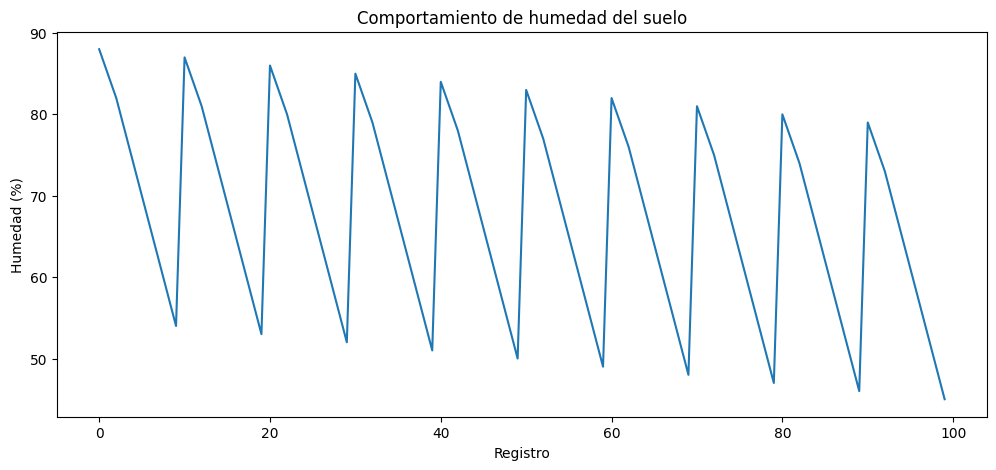

In [7]:
plt.figure(figsize=(12,5))

plt.plot(df["humedad"])

plt.title("Comportamiento de humedad del suelo")
plt.xlabel("Registro")
plt.ylabel("Humedad (%)")

plt.show()

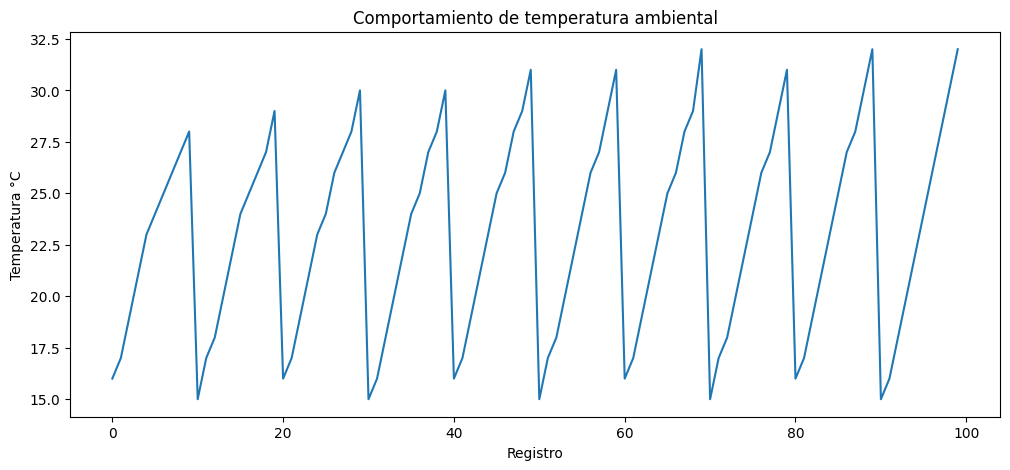

In [8]:
plt.figure(figsize=(12,5))

plt.plot(df["temperatura"])

plt.title("Comportamiento de temperatura ambiental")
plt.xlabel("Registro")
plt.ylabel("Temperatura °C")

plt.show()

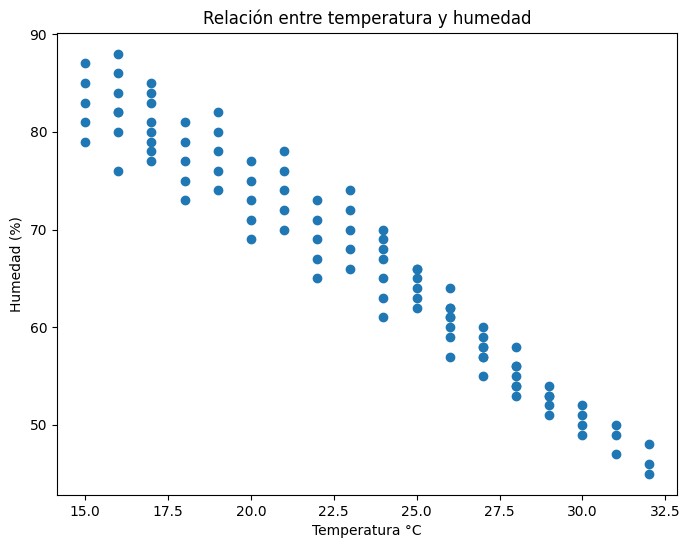

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(df["temperatura"], df["humedad"])

plt.title("Relación entre temperatura y humedad")
plt.xlabel("Temperatura °C")
plt.ylabel("Humedad (%)")

plt.show()

In [10]:
df["riesgo"].unique()

<StringArray>
['Bajo', 'Medio', 'Alto', 'Crítico']
Length: 4, dtype: str

In [11]:
df["riesgo_numerico"] = df["riesgo"].map({
    "Bajo": 0,
    "Medio": 1,
    "Alto": 2,
    "Crítico": 3
})

df.head()

,fecha,hora,humedad,temperatura,viento,luz_solar,riesgo,riesgo_numerico
0,2026-05-01,07:00,88,16,3,Baja,Bajo,0
1,2026-05-01,08:00,85,17,4,Baja,Bajo,0
2,2026-05-01,09:00,82,19,5,Media,Bajo,0
3,2026-05-01,10:00,78,21,6,Media,Bajo,0
4,2026-05-01,11:00,74,23,7,Media,Bajo,0


In [13]:
X = df[["humedad", "temperatura", "viento"]]

y = df["riesgo_numerico"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier()

modelo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
nuevo_dato = [[35, 30, 20]]

prediccion = modelo.predict(nuevo_dato)

print(prediccion)

[3]


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [17]:
import pandas as pd

nuevo_dato = pd.DataFrame({
    "humedad": [35],
    "temperatura": [30],
    "viento": [20]
})

prediccion = modelo.predict(nuevo_dato)

print(prediccion)

[3]
